# 전 자세 목각인형 검출기 학습

서기·앉기·눕기를 모두 `mannequin` 클래스 하나로 검출하는 YOLO11n 모델을 학습합니다. 검출 모델은 자세를 판정하지 않고 bbox만 만들며, 자세 판정은 이후 `detect_then_pose_webcam_test.py`의 crop Pose 단계가 담당합니다.

## Drive에 준비할 파일

- `mannequin_dataset.zip`: `mannequin_combined.coco`를 변환한 통합 YOLO Detection 데이터셋
- `rescue_yolo11n.pt`(선택): 기존 모델 가중치에서 이어 학습할 때 사용

통합 데이터에는 기존 눕기 데이터, 추가 서기 데이터, 빈 공간 hard-negative가 모두 포함됩니다. ZIP은 로컬의 `vision_training/tools/prepare_mannequin_colab_dataset.py`로 생성합니다.


In [1]:
!nvidia-smi
!pip -q install "ultralytics>=8.3,<9" pyyaml

Sun Aug  9 05:52:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             56W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

DRIVE_DIR = Path('/content/drive/MyDrive/mannequin_training')
DATASET_ZIP = DRIVE_DIR / 'mannequin_dataset.zip'
INITIAL_WEIGHTS = DRIVE_DIR / 'rescue_yolo11n.pt'
OUTPUT_DIR = DRIVE_DIR / 'runs'

if not DATASET_ZIP.is_file():
    raise FileNotFoundError(f'Drive에 통합 데이터 ZIP이 없습니다: {DATASET_ZIP}')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('통합 데이터:', DATASET_ZIP)
print('초기 가중치:', INITIAL_WEIGHTS if INITIAL_WEIGHTS.is_file() else 'yolo11n.pt (COCO)')


Mounted at /content/drive
통합 데이터: /content/drive/MyDrive/mannequin_training/mannequin_dataset.zip
초기 가중치: /content/drive/MyDrive/mannequin_training/rescue_yolo11n.pt


## 통합 데이터 압축 해제 및 검증

로컬에서 이미 병합·분할한 `mannequin_dataset.zip` 하나를 사용합니다. class 0은 `mannequin`, class 1은 `helping_person`이며, 빈 공간 hard-negative는 내용이 비어 있는 라벨 파일로 유지됩니다.


In [4]:
import shutil
import zipfile
from collections import Counter

WORK = Path('/content/mannequin_training')
if WORK.exists():
    shutil.rmtree(WORK)
WORK.mkdir(parents=True)

with zipfile.ZipFile(DATASET_ZIP) as archive:
    archive.extractall(WORK)

yaml_candidates = list(WORK.rglob('data.yaml'))
if len(yaml_candidates) != 1:
    raise RuntimeError(f'data.yaml이 정확히 하나여야 합니다: {yaml_candidates}')
data_yaml = yaml_candidates[0]
DATASET_ROOT = data_yaml.parent
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
stats = Counter()

for split in ('train', 'val', 'test'):
    image_dir = DATASET_ROOT / 'images' / split
    label_dir = DATASET_ROOT / 'labels' / split
    if not image_dir.is_dir() or not label_dir.is_dir():
        raise RuntimeError(f'{split} 이미지/라벨 폴더가 없습니다.')
    images = [p for p in image_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS]
    for image in images:
        label = label_dir / f'{image.stem}.txt'
        if not label.is_file():
            raise RuntimeError(f'라벨 파일 누락: {label}')
        lines = [line.strip() for line in label.read_text().splitlines() if line.strip()]
        for line in lines:
            fields = line.split()
            if len(fields) != 5:
                raise RuntimeError(f'YOLO Detection 5필드가 아닙니다: {label}: {line}')
            class_id = int(fields[0])
            if class_id not in (0, 1):
                raise RuntimeError(f'허용하지 않는 class {class_id}: {label}')
            values = [float(value) for value in fields[1:]]
            if any(value < 0.0 or value > 1.0 for value in values):
                raise RuntimeError(f'정규화 범위를 벗어난 bbox: {label}: {line}')
            stats[f'class_{class_id}'] += 1
        stats[f'{split}_images'] += 1
        stats['positive_images' if lines else 'empty_images'] += 1

if stats['class_0'] == 0:
    raise RuntimeError('mannequin(class 0) bbox가 없습니다.')
print('데이터 루트:', DATASET_ROOT)
print('data.yaml:', data_yaml)
print('통계:', dict(stats))


데이터 루트: /content/mannequin_training/mannequin_dataset
data.yaml: /content/mannequin_training/mannequin_dataset/data.yaml
통계: {'class_0': 901, 'train_images': 729, 'positive_images': 901, 'class_1': 207, 'empty_images': 10, 'val_images': 91, 'test_images': 91}


In [5]:
import yaml

config = yaml.safe_load(data_yaml.read_text())
expected_names = {0: 'mannequin', 1: 'helping_person'}
actual_names = {int(key): value for key, value in config.get('names', {}).items()}
if actual_names != expected_names:
    raise RuntimeError(f'클래스 구성이 다릅니다: {actual_names} != {expected_names}')

# ZIP이 어디에 풀려도 현재 Colab 절대 경로를 사용하도록 고정합니다.
config['path'] = str(DATASET_ROOT)
data_yaml.write_text(yaml.safe_dump(config, sort_keys=False, allow_unicode=True))
print(data_yaml.read_text())


path: /content/mannequin_training/mannequin_dataset
train: images/train
val: images/val
test: images/test
names:
  0: mannequin
  1: helping_person



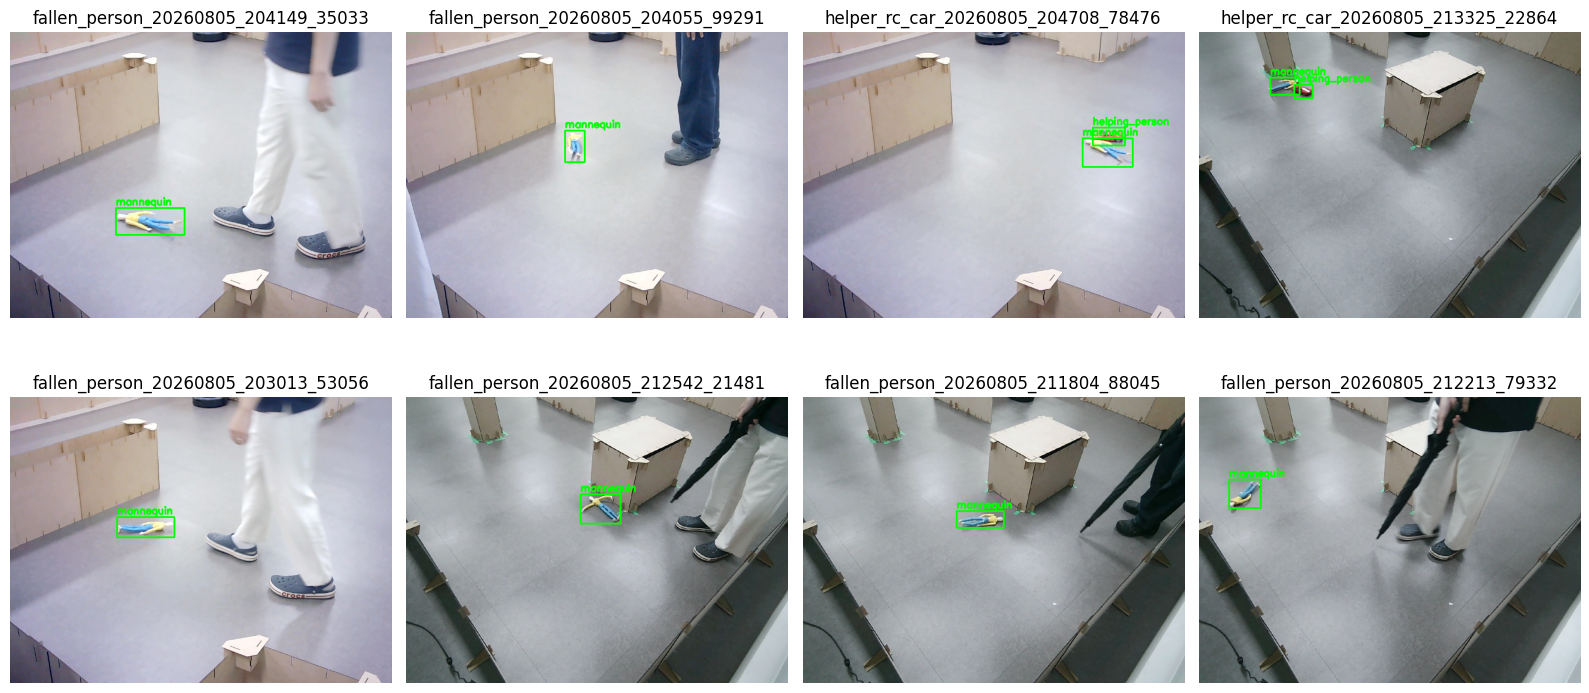

In [6]:
import random
import cv2
import matplotlib.pyplot as plt

CLASS_NAMES = {0: 'mannequin', 1: 'helping_person'}

def draw_labels(image_path: Path):
    split = image_path.parent.name
    label_path = DATASET_ROOT / 'labels' / split / f'{image_path.stem}.txt'
    image = cv2.imread(str(image_path))
    height, width = image.shape[:2]
    for line in label_path.read_text().splitlines():
        if not line.strip():
            continue
        class_id, cx, cy, bw, bh = map(float, line.split())
        x1, y1 = int((cx - bw / 2) * width), int((cy - bh / 2) * height)
        x2, y2 = int((cx + bw / 2) * width), int((cy + bh / 2) * height)
        class_id = int(class_id)
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image, CLASS_NAMES[class_id], (x1, max(y1 - 5, 18)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 0), 2)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

train_images = [
    p for p in (DATASET_ROOT / 'images' / 'train').iterdir()
    if p.suffix.lower() in IMAGE_EXTS
]
samples = random.sample(train_images, min(8, len(train_images)))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for axis in axes.flat:
    axis.axis('off')
for axis, sample in zip(axes.flat, samples):
    axis.imshow(draw_labels(sample))
    axis.set_title(sample.name[:35])
plt.tight_layout()
plt.show()


## YOLO11n 학습

기존 `rescue_yolo11n.pt`가 Drive에 있으면 이를 초기 가중치로 사용합니다. 없으면 COCO `yolo11n.pt`에서 시작합니다. 


In [7]:
import torch
from ultralytics import YOLO

EPOCHS = 100
BATCH = 16
IMGSZ = 640
DEVICE = 0 if torch.cuda.is_available() else 'cpu'
start_weights = str(INITIAL_WEIGHTS) if INITIAL_WEIGHTS.is_file() else 'yolo11n.pt'
model = YOLO(start_weights)
model.train(
    data=str(data_yaml), epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH,
    device=DEVICE, workers=8, patience=20, seed=42, deterministic=True,
    project=str(OUTPUT_DIR), name='mannequin_yolo11n', plots=True,
    scale=0.7, degrees=15.0, translate=0.15, fliplr=0.5,
    close_mosaic=10, exist_ok=True,
)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/mannequin_training/mannequin_dataset/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dfa51fe6540>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [8]:
run_dir = OUTPUT_DIR / 'mannequin_yolo11n'
best = run_dir / 'weights' / 'best.pt'
if not best.is_file():
    raise FileNotFoundError(best)
best_model = YOLO(str(best))
print('classes:', best_model.names)
val_result = best_model.val(data=str(data_yaml), split='val', imgsz=IMGSZ, device=DEVICE, plots=True)
test_result = best_model.val(data=str(data_yaml), split='test', imgsz=IMGSZ, device=DEVICE, plots=True, name='mannequin_yolo11n_test')
print('best:', best)
print('test mAP50:', float(test_result.box.map50))
print('test mAP50-95:', float(test_result.box.map))

classes: {0: 'mannequin', 1: 'helping_person'}
Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1945.2±531.7 MB/s, size: 71.0 KB)
val: Scanning /content/mannequin_training/mannequin_dataset/labels/val.cache... 91 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 91/91 29.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 4.5it/s 1.3s0.7s
                   all         91        116      0.992      0.993      0.995      0.685
             mannequin         91         91      0.983          1      0.994       0.71
        helping_person         25         25          1      0.986      0.995       0.66
Speed: 2.0ms preprocess, 2.7ms inference, 0.0ms loss, 5.5ms postprocess per image
Results saved to /content/runs/detect/val
Ultralytics 8

In [9]:
from google.colab import files

final_weights = DRIVE_DIR / 'mannequin_yolo11n_best.pt'
shutil.copy2(best, final_weights)
archive_base = Path('/content/mannequin_yolo11n_results')
archive = shutil.make_archive(str(archive_base), 'zip', run_dir)
print('Drive 가중치:', final_weights)
print('결과 ZIP:', archive)
files.download(str(best))
files.download(archive)

Drive 가중치: /content/drive/MyDrive/mannequin_training/mannequin_yolo11n_best.pt
결과 ZIP: /content/mannequin_yolo11n_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 로컬 웹캠 테스트

다운로드한 `best.pt`를 프로젝트 PC로 복사한 뒤 다음처럼 실행합니다. `--target mannequin`은 기본 모델 선택과 화면 이름을 지정하며, 실제 detector는 `--detector-weights`에 준 새 모델을 사용합니다.

```bash
/usr/bin/python3 vision_training/testing/detect_then_pose_webcam_test.py \
  --source 0 \
  --target mannequin \
  --detector-weights /absolute/path/mannequin_yolo11n_best.pt \
  --det-conf 0.25 --pose-conf 0.10 --keypoint-conf 0.15
```

평가할 때는 객체 bbox가 나왔는지와 Pose 관절이 나왔는지를 따로 기록합니다. bbox는 나오지만 관절이 나오지 않는다면 1단계 mannequin 검출은 해결됐고 2단계 사람용 Pose의 도메인 한계가 남은 것입니다.